<a href="https://colab.research.google.com/github/JuanSamaniego02/curso-ia-para-economia/blob/main/Dataton_DanaMendoza_AlanRios_JuanSamaniego.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RETO 1

In [2]:
pd.read_csv("/content/banco_clientes.csv")
clientes = pd.read_csv("/content/banco_clientes.csv")

In [3]:
pd.read_csv("/content/banco_transacciones.csv")
transacciones = pd.read_csv("/content/banco_transacciones.csv")

In [4]:
df = pd.merge(clientes, transacciones, on="ID_Cliente", how="left")

print(df.shape)
df.head(3)

(1000, 7)


,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,1,46.033413,2.812419e+06,F,2058.469892,1.0,0.0
1,2,61.556330,8.323278e+05,Otro,2581.611324,1.0,1.0
2,3,48.472947,2.694336e+06,M,6285.609334,4.0,0.0


RETO 2

In [5]:
df.isna().sum()

,0
ID_Cliente,0
Edad,50
Ingreso_Mensual,100
Genero,0
Saldo_Cuenta,100
Cant_Productos,100
Fuga_Ultimo_Mes,100


In [6]:
df["Genero"] = df["Genero"].str.lower().str.strip()

# Estandarizar categorías
df["Genero"] = df["Genero"].replace({
    "f": "Femenino",
    "femenino": "Femenino",
    "m": "Masculino",
    "masculino": "Masculino",
    "otro": "Otro"
})

# Manejar nulos y valores raros
df["Genero"] = df["Genero"].fillna("Otro")
df.loc[~df["Genero"].isin(["Femenino", "Masculino", "Otro"]), "Genero"] = "Otro"

In [7]:
df = df.copy()

df["Edad"] = df["Edad"].fillna(df["Edad"].median())
df["Ingreso_Mensual"] = df["Ingreso_Mensual"].fillna(df["Ingreso_Mensual"].median())
df["Saldo_Cuenta"] = df["Saldo_Cuenta"].fillna(0)
df["Cant_Productos"] = df["Cant_Productos"].fillna(0)
df["Fuga_Ultimo_Mes"] = df["Fuga_Ultimo_Mes"].fillna(1)


# Edad:
# Se imputa con la mediana, ya que es una medida robusta frente a valores atípicos
# y permite representar adecuadamente la edad típica de los clientes sin sesgar
# la distribución.

# Ingreso_Mensual:
# Se rellena con la mediana debido a la posible presencia de valores extremos
# (ingresos muy altos o muy bajos). Esto evita que la imputación se vea afectada
# por la dispersión de la variable.

# Saldo_Cuenta:
# Se imputa con 0 bajo el supuesto establecido en el enunciado: si no existe
# información de transacciones, se asume que el cliente no tiene productos
# financieros activos en el banco.

# Cant_Productos:
# Se rellena con 0, ya que la ausencia de registros de productos indica que
# el cliente no tiene productos asociados.

# Fuga_Ultimo_Mes:
# Se completa con 1 (fuga), interpretando que la falta de actividad o de
# información transaccional puede asociarse con abandono del cliente.

In [18]:
df.loc[df["Edad"] > 100, "Edad"] = df.loc[df["Edad"] <= 100, "Edad"].median()

Se utiliza la mediana para remplazar un outlier o un valor extremo con un valor mas representativo. en este caso la mediana, debido a que el 150 se considera un valor poco realista y por ende un error de digitacion

RETO 3

In [9]:
df["Ingreso_Anual"] = df["Ingreso_Mensual"] * 12

In [10]:
resumen = df.groupby(["Genero", "Fuga_Ultimo_Mes"])["Saldo_Cuenta"].mean()
print(resumen)

Genero     Fuga_Ultimo_Mes
Femenino   0.0                8585.978703
           1.0                1297.907669
Masculino  0.0                7371.789321
           1.0                 835.177891
Otro       0.0                8474.819616
           1.0                 933.561425
Name: Saldo_Cuenta, dtype: float64


RETO 4

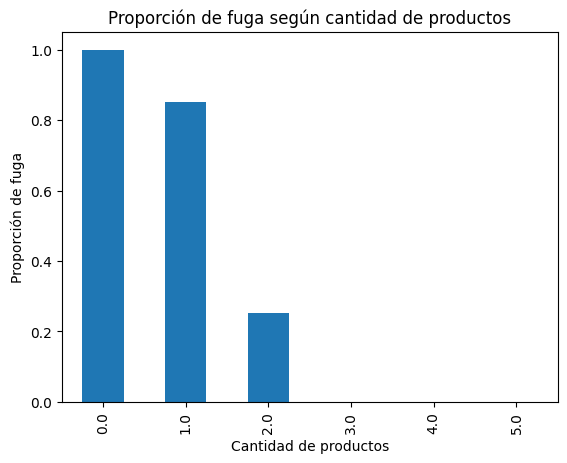

In [11]:
fuga_productos = df.groupby("Cant_Productos")["Fuga_Ultimo_Mes"].mean()

fuga_productos.plot(kind="bar")
plt.title("Proporción de fuga según cantidad de productos")
plt.ylabel("Proporción de fuga")
plt.xlabel("Cantidad de productos")
plt.show()

El análisis evidencia que la fuga de clientes no es un fenómeno aleatorio, sino que responde a factores estructurales relacionados con el nivel de vinculación financiera y las características económicas de los clientes.

En primer lugar, se observa que los clientes con 0 o 1 producto presentan tasas de fuga extremadamente altas, cercanas al 100% y 85% respectivamente, mientras que aquellos con 2 o más productos reducen significativamente su probabilidad de abandono. Esto sugiere que existe una relación inversa entre el número de productos y la fuga, explicada por los costos de cambio: a mayor vinculación, mayor dificultad para abandonar la entidad.

En conjunto, estos resultados indican que la fuga se concentra en clientes con baja vinculación y menor ingreso, lo que evidencia una falla en la estrategia de integración y retención del banco, especialmente en las etapas iniciales del ciclo de vida del cliente.


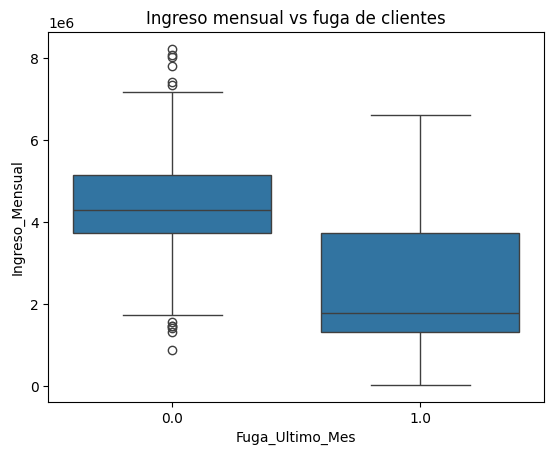

In [12]:
sns.boxplot(x="Fuga_Ultimo_Mes", y="Ingreso_Mensual", data=df)
plt.title("Ingreso mensual vs fuga de clientes")
plt.show()

De acuerdo a la gráfica, podemos observar que los clientes que no se fugan tienen, en promedio, considerablemente más altos. Por otro lado, los que si se fugan tienen ingresos más bajos y dispersos.


### Recomendaciones Estratégicas

1. Estrategia de vinculación temprana:
Se recomienda incentivar la adquisición de múltiples productos desde las primeras etapas de relación con el cliente, con el fin de aumentar los costos de cambio y reducir la probabilidad de fuga.

2. Segmentación por nivel de ingreso:
Diseñar productos diferenciados según la capacidad económica del cliente, ofreciendo alternativas de bajo costo para segmentos vulnerables y beneficios exclusivos para clientes de mayor ingreso.

3. Sistema de alerta temprana:
Identificar clientes en riesgo, especialmente aquellos con 0 o 1 producto y bajos niveles de ingreso, para implementar acciones de retención oportunas.

4. Programas de fidelización:
Implementar incentivos como cashback, tasas preferenciales o beneficios adicionales que aumenten la permanencia del cliente.

5. Mejora en el proceso de onboarding:
Fortalecer la experiencia inicial del cliente con el banco, promoviendo una mayor integración desde el inicio de la relación.

RETO 5

In [13]:
df = pd.get_dummies(df, columns=["Genero"], drop_first=True)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [15]:
df[["Ingreso_Mensual", "Saldo_Cuenta"]] = scaler.fit_transform(
    df[["Ingreso_Mensual", "Saldo_Cuenta"]]
)

In [16]:
df.head()

,ID_Cliente,Edad,Ingreso_Mensual,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Ingreso_Anual,Genero_Masculino,Genero_Otro
0,1,46.033413,-0.597392,-0.542484,1.0,0.0,3.374903e+07,False,False
1,2,61.556330,-1.874296,-0.467535,1.0,1.0,9.987934e+06,False,True
2,3,48.472947,-0.673541,0.063122,4.0,0.0,3.233203e+07,True,False
3,4,37.087825,1.079046,1.511478,4.0,0.0,6.494481e+07,False,False
4,5,39.298402,0.554676,1.402124,3.0,0.0,5.518713e+07,True,False


In [17]:
df.isna().sum()

,0
ID_Cliente,0
Edad,0
Ingreso_Mensual,0
Saldo_Cuenta,0
Cant_Productos,0
Fuga_Ultimo_Mes,0
Ingreso_Anual,0
Genero_Masculino,0
Genero_Otro,0
